In [66]:
# Paths to skip CosineSim(GPT-4-Turbo, Claude-3.5-Sonnet) < 0.65
reject_65=[]

In [67]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 14,           # Default font size
    'axes.titlesize': 16,      # Title font size
    'axes.labelsize': 14,      # Axis label size
    'xtick.labelsize': 12,     # X tick label size
    'ytick.labelsize': 12,     # Y tick label size
    'legend.fontsize': 12,     # Legend font size
    'figure.titlesize': 16     # Figure title font size
})


In [68]:
json_dir = '../evaluation/'
raw_counts = []

In [69]:
def compute_final_only_probs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    only_final_counts = defaultdict(int)
    not_before_final_counts = defaultdict(int)
    
    for entry in data:
        path = entry.get("path", [])
        if not path:
            continue

        all_prev_halls_by_type = defaultdict(set)
        final_step_halls_by_type = defaultdict(set)

        for i, step in enumerate(path):
            if step["question_id"] in reject_65:
                # Skip questions with low cosine-similarity
                break

            if len(path) == 1:
                # Skip if there is no progressive path
                break
                
            hallucinations = step.get("hallucination", [])
            halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

            if i == len(path) - 1:
                for h in halluc_set:
                    htype = h[0]
                    final_step_halls_by_type[htype].add(h)
            else:
                for h in halluc_set:
                    htype = h[0]
                    all_prev_halls_by_type[htype].add(h)

        for htype in hallucination_types:
            prev = all_prev_halls_by_type[htype]
            final = final_step_halls_by_type[htype]

            unseen_in_prev = final - prev

            if unseen_in_prev:
                only_final_counts[htype] += 1
            if not prev:
                not_before_final_counts[htype] += 1
                
    final_only_given_not_before = {
        htype: only_final_counts[htype] / not_before_final_counts[htype]
        if not_before_final_counts[htype] > 0 else 0
        for htype in hallucination_types
    }

    total_paths = len(data)
    only_final_probs = {
        htype: only_final_counts[htype] / total_paths for htype in hallucination_types
    }

    return final_only_given_not_before


def compute_occurs_before_probs(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    before_final_counts = defaultdict(int)
    before_and_final_counts = defaultdict(int)

    for entry in data:
        path = entry.get("path", [])
        if not path:
            continue

        all_prev_halls_by_type = defaultdict(set)
        final_step_halls_by_type = defaultdict(set)

        for i, step in enumerate(path):
            if step["question_id"] in reject_65:
                # Skip questions with low cosine-similarity
                break

            if len(path) == 1:
                # Skip if there is no progressive path
                break

            hallucinations = step.get("hallucination", [])
            halluc_set = {(h[0], h[1]) for h in hallucinations if isinstance(h, list) and len(h) >= 2}

            if i == len(path) - 1:
                for h in halluc_set:
                    htype = h[0]
                    final_step_halls_by_type[htype].add(h)
            else:
                for h in halluc_set:
                    htype = h[0]
                    all_prev_halls_by_type[htype].add(h)

        for htype in hallucination_types:
            prev = all_prev_halls_by_type[htype]
            final = final_step_halls_by_type[htype]

            if prev:
                before_final_counts[htype] += 1
            if prev & final:
                before_and_final_counts[htype] += 1

    conditional_probs = {
        htype: before_and_final_counts[htype] / before_final_counts[htype]
        if before_final_counts[htype] > 0 else 0
        for htype in hallucination_types
    }
    
    return conditional_probs


def compute_total_counts(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    total_counts = defaultdict(int)

    for entry in data:
        path = entry.get("path", [])
        if not path:
            continue

        for step in path:
            if step["question_id"] in reject_65:
                break
            hallucinations = step.get("hallucination", [])
            for h in hallucinations:
                if isinstance(h, list) and len(h) >= 2:
                    htype = h[0]
                    total_counts[htype] += 1

    return total_counts

In [70]:
json_filenames = [
    'path_eval_log_paper_path_hallu_3_5_claude.json',
    'path_eval_log_paper_path_hallu_3_7_claude.json',
    'path_eval_log_paper_path_halluc_4_1_mini.json',
    'path_eval_log_paper_path_halluc_4_0_turbo.json',
    'path_eval_log_paper_path_halluc_4_0_o_mini.json',
    
]

key_names = [
    'Claude-3.5-sonnet',
    'Claude-3.7-sonnet',
    'GPT-4.1-mini',
    'GPT-4.0-turbo',
    'GPT-4o-mini',
    
]

# === 2. Hallucination types and colors ===
hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

hallucination_labels = [
    "Schema\nContradiction",
    "Attribute\nOveranalysis",
    "Value\nMisrepresentation",
    "Clause\nAbuse",
    "Mathematical\nDelusion",
    "Join\nRedundancy"
]

colors = ['#377eb8','#ff7f00', '#4daf4a','#e41a1c', '#984ea3', '#ffff33', '#a65628', '#f781bf', '#999999'] # one color per file


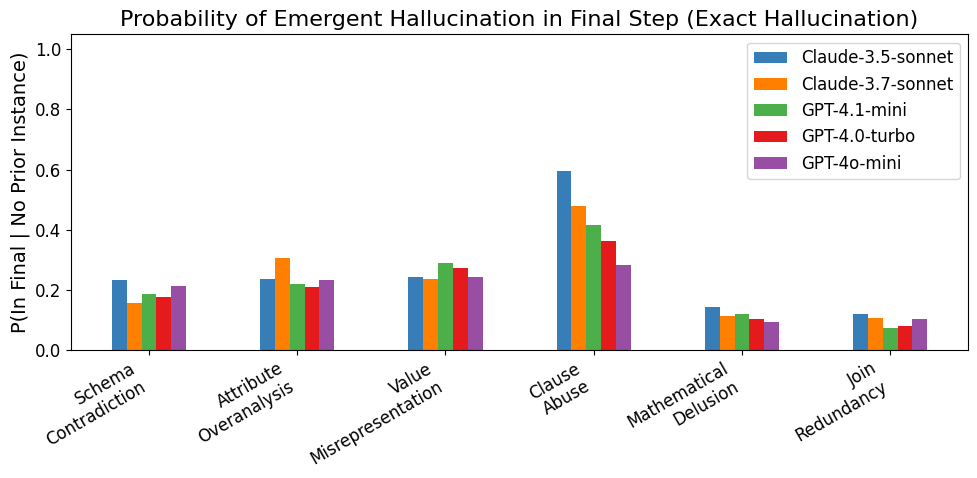

In [71]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import numpy as np

all_probs = []
for fname in json_filenames:
    path_to_file = os.path.join(json_dir, fname)
    probs = compute_final_only_probs(path_to_file)
    all_probs.append(probs)
    # raw_counts.append((only_final, not_before))


x = np.arange(len(hallucination_types))
width = 0.1

fig, ax = plt.subplots(figsize=(10, 5))

for i, probs in enumerate(all_probs):
    values = [probs[ht] for ht in hallucination_types]
    ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
           label=key_names[i], color=colors[i])


ax.set_ylabel("P(In Final | No Prior Instance)")
ax.set_title("Probability of Emergent Hallucination in Final Step (Exact Hallucination)")
ax.set_xticks(x)
ax.set_xticklabels(hallucination_labels, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.legend()



plt.tight_layout()
plt.show()


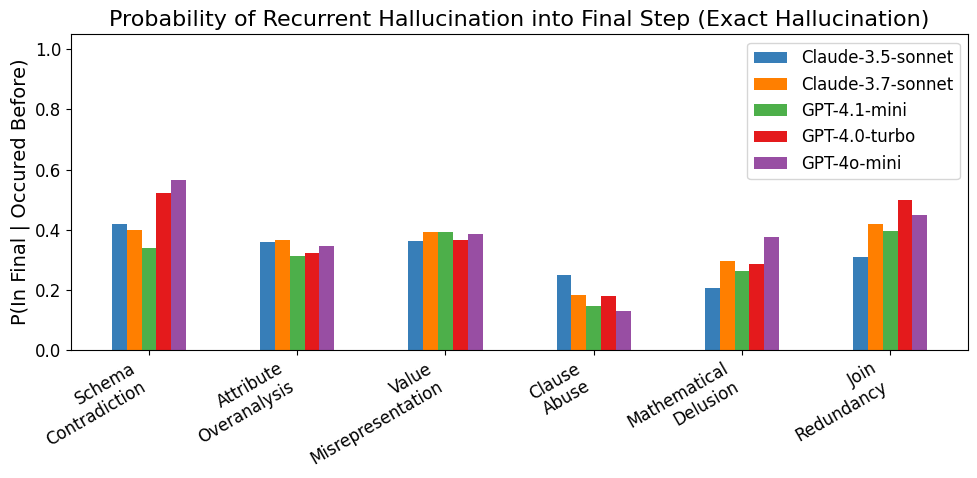

In [72]:
all_probs = []
for fname in json_filenames:
    full_path = os.path.join(json_dir, fname)
    probs = compute_occurs_before_probs(full_path)
    all_probs.append(probs)

x = np.arange(len(hallucination_types))
width = 0.1

fig, ax = plt.subplots(figsize=(10, 5))

for i, probs in enumerate(all_probs):
    values = [probs[ht] for ht in hallucination_types]
    ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
           label=key_names[i], color=colors[i])

ax.set_ylabel("P(In Final | Occured Before)")
ax.set_title("Probability of Recurrent Hallucination into Final Step (Exact Hallucination)")
ax.set_xticks(x)
ax.set_xticklabels(hallucination_labels, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.legend()


plt.tight_layout()
plt.show()

In [73]:
json_filenames = [
    'path_eval_log_paper_path_hallu_3_5_claude_history.json',
    'path_eval_log_paper_path_hallu_3_5_claude.json',
    'path_eval_log_paper_path_hallu_3_7_claude_history.json',
    'path_eval_log_paper_path_hallu_3_7_claude.json',
    'path_eval_log_paper_path_halluc_4_1_mini_history.json',
    'path_eval_log_paper_path_halluc_4_1_mini.json',
    'path_eval_log_paper_path_halluc_4_0_turbo_history.json',
    'path_eval_log_paper_path_halluc_4_0_turbo.json',
    'path_eval_log_paper_path_halluc_4_0_o_mini_history.json',
    'path_eval_log_paper_path_halluc_4_0_o_mini.json',
    
]

key_names = [
    'Claude-3.5-sonnet (+ History)',
    'Claude-3.5-sonnet',
    'Claude-3.7-sonnet (+ History)',
    'Claude-3.7-sonnet',
    'GPT-4.1-mini (+ History)',
    'GPT-4.1-mini',
    'GPT-4.0-turbo (+ History)',
    'GPT-4.0-turbo',
    'GPT-4o-mini (+ History)',
    'GPT-4o-mini',
    'GPT-4o (+ History)',
    'GPT-4o',
    
]

hallucination_types = [
    "Schema-Based: Schema Contradiction",
    "Schema-Based: Attribute Overanalysis",
    "Schema-Based: Value Misrepresentation",
    "Logic-Based: Clause Abuse",
    "Logic-Based: Mathematical Delusion",
    "Logic-Based: Join Redundancy"
]

hallucination_labels = [
    "Schema\nContradiction",
    "Attribute\nOveranalysis",
    "Value\nMisrepresentation",
    "Clause\nAbuse",
    "Mathematical\nDelusion",
    "Join\nRedundancy"
]

colors = ['#377eb8','#377eb8', '#ff7f00','#ff7f00', '#4daf4a','#4daf4a', '#e41a1c','#e41a1c', '#984ea3','#984ea3', '#ffff33','#ffff33', '#a65628','#a65628', '#f781bf','#f781bf', '#999999''#999999'] # one color per file


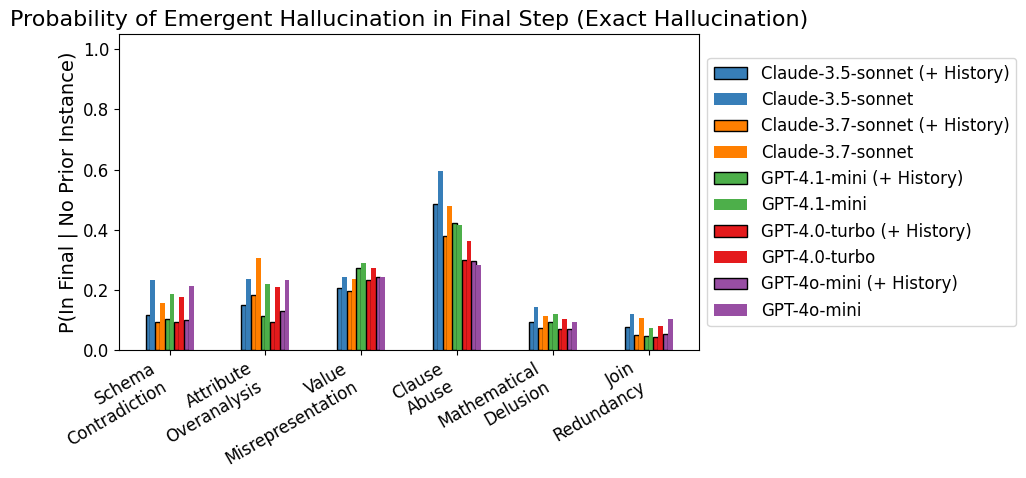

In [74]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import numpy as np

all_probs = []
for fname in json_filenames:
    path_to_file = os.path.join(json_dir, fname)
    probs = compute_final_only_probs(path_to_file)
    all_probs.append(probs)
    # raw_counts.append((only_final, not_before))


x = np.arange(len(hallucination_types))
width = 0.05

fig, ax = plt.subplots(figsize=(10, 5))

for i, probs in enumerate(all_probs):
    values = [probs[ht] for ht in hallucination_types]
    if i % 2 == 0:
        ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
               label=key_names[i], color=colors[i], edgecolor="black")
    else:
        ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
               label=key_names[i], color=colors[i])


ax.set_ylabel("P(In Final | No Prior Instance)")
ax.set_title("Probability of Emergent Hallucination in Final Step (Exact Hallucination)")
ax.set_xticks(x)
ax.set_xticklabels(hallucination_labels, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


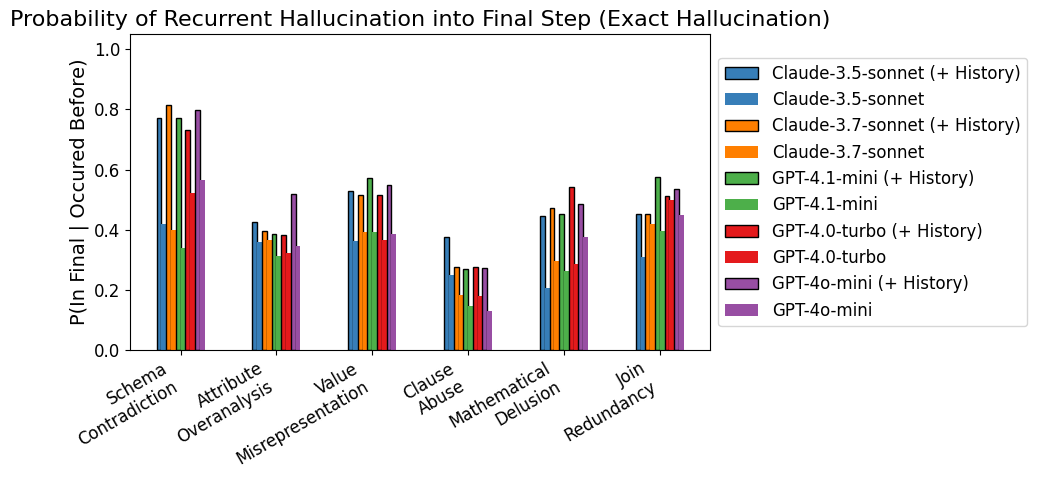

In [75]:
all_probs = []
for fname in json_filenames:
    full_path = os.path.join(json_dir, fname)
    probs = compute_occurs_before_probs(full_path)
    all_probs.append(probs)

x = np.arange(len(hallucination_types))
width = 0.05 

fig, ax = plt.subplots(figsize=(10, 5))

for i, probs in enumerate(all_probs):
    values = [probs[ht] for ht in hallucination_types]
    if i % 2 == 0:
        ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
               label=key_names[i], color=colors[i], edgecolor="black")
    else:
        ax.bar(x + i * width - width*(len(all_probs)-1)/2, values, width,
               label=key_names[i], color=colors[i])

ax.set_ylabel("P(In Final | Occured Before)")
ax.set_title("Probability of Recurrent Hallucination into Final Step (Exact Hallucination)")
ax.set_xticks(x)
ax.set_xticklabels(hallucination_labels, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

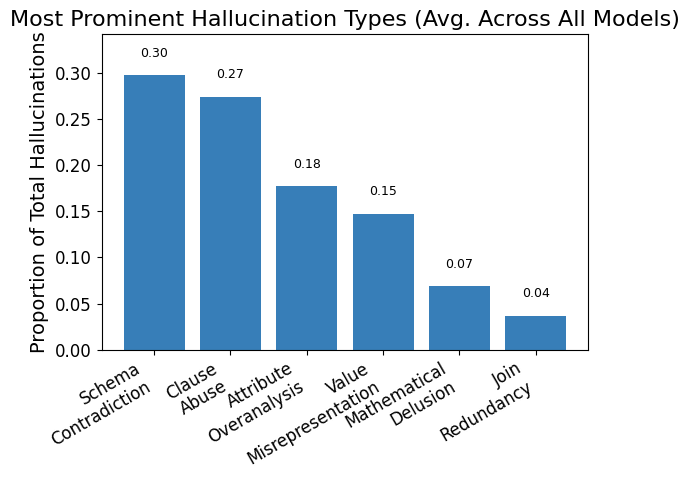

In [76]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt

combined_counts = defaultdict(int)

for fname in json_filenames:
    full_path = os.path.join(json_dir, fname)
    model_counts = compute_total_counts(full_path)
    for htype in hallucination_types:
        combined_counts[htype] += model_counts[htype]

total_all = sum(combined_counts.values())
proportions = {htype: combined_counts[htype] / total_all for htype in hallucination_types}

sorted_items = sorted(proportions.items(), key=lambda x: x[1], reverse=True)
sorted_labels = [hallucination_labels[hallucination_types.index(k)] for k, _ in sorted_items]
sorted_values = [v for _, v in sorted_items]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(sorted_labels, sorted_values, color='#377eb8')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', fontsize=9)


ax.set_ylabel("Proportion of Total Hallucinations")
ax.set_title("Most Prominent Hallucination Types (Avg. Across All Models)")
ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=30, ha='right')
ax.set_ylim(0, max(sorted_values) * 1.15)

plt.tight_layout()
plt.show()
